# Анализ данных — занятие 3
### Проверка статистических гипотез

**Логика занятия:** зачем нужны гипотезы и статистики → что такое p-value и уровень значимости → как проверить связь двух величин (корреляция Пирсона) → одно выборочные Z- и t-критерии → двухвыборочный критерий для сравнения двух групп.

## Гипотезы, статистика и p-value

- **Нулевая гипотеза H0** — то, во что проще всего поверить: «корреляции нет», «средние равны». **Альтернативная H1** — противоположное утверждение. Формулировка «не зелёный» исчерпывает все варианты, а «красный» — нет.
- **Статистика** — любая функция от выборки случайных величин (среднее, коэффициент корреляции и т. п.). Сама статистика тоже случайная величина.
- **p-value** — вероятность (площадь под распределением статистики) получить наблюдаемое или более крайнее значение при условии, что H0 верна.
- **Уровень значимости** α по умолчанию равен `0.05`, что соответствует доверительному интервалу 95%. Правило: `p > 0.05` → H0 не отвергаем; `p < 0.05` → отвергаем H0.

Доверительный интервал нормального распределения: в ±1σ попадает ~68% значений, в ±2σ — ~95% (по 2.5% в каждом хвосте).

In [6]:
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt


## Корреляция Пирсона: сила эффекта против наличия эффекта

`scipy.stats.pearsonr` возвращает два числа:

- `R` — коэффициент корреляции, **сила эффекта**: насколько сильно величины связаны (от −1 до 1). Судить по одному `R` нельзя: вывод «больше половины — значит корреляция есть» неверен.
- `p-value` — **наличие эффекта**: отвечает на вопрос, коррелируют ли величины вообще. Если `p > 0.05`, корреляции нет, даже когда `R` выглядит большим.

Нулевая гипотеза здесь — «корреляции нет».

In [7]:
N = 10
d=[]
x = np.random.rand(N)
y = np.random.rand(N)
R, pv = ss.pearsonr(x, y)
print('pv', pv)


pv 0.07406186493484672


## Коэффициент корреляции — случайная величина

Так как `R` считается по случайным данным, сам он тоже случаен: при повторной генерации он может принимать значения от −0.8 до 0.8 и без всякой реальной связи. Поэтому строят распределение `R` и его доверительный интервал (`mean ± 2*std`). Если ноль попадает внутрь интервала — корреляции нет; если ноль вне интервала — корреляция есть. Это то же самое, что смотреть на p-value.

-0.08223741832350179 1.0798512357187857


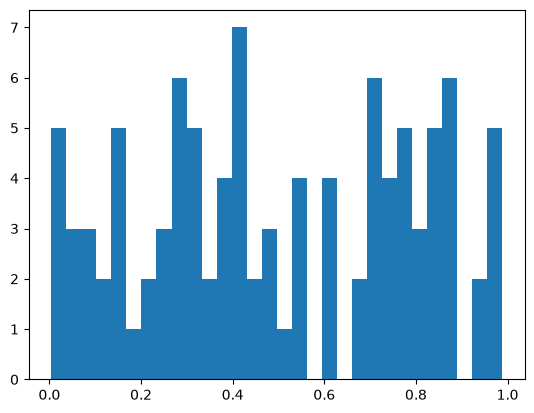

In [8]:
for i in range(100):
    x = np.random.rand(N)
    y = np.random.rand(N)
    R, pv = ss.pearsonr(x, y)
    # print(R, pv)
    d.append(pv)
d = np.array(d)
plt.hist(d, bins=30)
print(d.mean()-2*d.std(), d.mean()+2*d.std())

## Ошибки I и II рода, мощность критерия

При проверке гипотез возможны две ошибки: отвергнуть верную H0 (ошибка I рода, её вероятность равна α) и не отвергнуть неверную H0 (ошибка II рода, вероятность β). Величина `1 − β` называется **мощностью критерия**: чем она выше, тем лучше критерий различает гипотезы. При α = 0.05 мы в 5% случаев отвергаем верные гипотезы.

## Одно выборочный критерий: Z и t

Есть одна выборка, нужно проверить утверждение о её среднем (например, «преподаватель в среднем ставит 4»).

- **Z-критерий** — если среднее квадратичное отклонение генеральной совокупности `σ` известно: `Z = (x̄ − μ0) / (σ0 / √n)`. По центральной предельной теореме среднее распределено нормально, поэтому 95% доверительный интервал — это ±2σ. Если `|Z| > 2`, значение выпадает из интервала и H0 отвергается.
- **t-критерий (Стьюдента)** — если `σ` неизвестно и считается по выборке: формула та же, но вместо `σ0` подставляется выборочное `s`, а статистика распределена по Стьюденту с числом степеней свободы `df = n − 1` (одну отнимаем для несмещённой оценки). При больших `n` распределение Стьюдента переходит в нормальное.
- **p-value для t**: `p = 2 * (1 − CDF(|t|))`; множитель 2 нужен из-за двустороннего интервала, а `CDF` берётся от модуля `t`.

In [29]:
x = np.array([5]*3+[3]*10)
xm = x.mean()

m0 = 3.9
s0 = 1
Z = (xm - m0) / (s0/np.sqrt(13))
s0 = x.std()
print(f"s0 = {s0} \n -------")
T = (xm - m0) / (s0/np.sqrt(13))
student = ss.t(23-1)
pv = (1 - student.cdf(abs(T)))*2
if pv > 0.05:
    print('teacher true')
else:
    print("teacher sovral")
# print(xm)
print(f"Z = {Z}")

s0 = 0.8426500884694864 
 -------
teacher true
Z = -1.580895559241902


## Пример: лекарство или плацебо

Стандартная процедура даёт выздоровление `0.9`, новое лекарство — 95 человек из 100. Разница `0.95` против `0.9` может быть случайной вариацией, поэтому проверяем гипотезу.

H0: средний уровень выздоровления равен `0.9`. Считаем t-статистику (`σ` неизвестно), `df = 100 − 1`. Если статистика выходит за границы доверительного интервала и `p < 0.05`, H0 отвергается и лекарство действительно работает; иначе это плацебо (гомеопатия). Вывод всегда даётся с вероятностью 95%.

In [1]:
observed = np.ones(100)
observed[:5]=0
Mu=0.9
Xm=observed.mean()
Std=observed.std()
N=observed.shape[0]
T = (Xm - Mu) / (Std/np.sqrt(N))
print(f"T={T}")
D = ss.t(df=99)
D.ppf(0.025), D.ppf(0.975)
pv = (1-D.cdf(abs(T)))*2
if (pv > 0.05):
    print('placheb')
else:
    print('lecarstvo')



T=2.2941573387056136
lecarstvo


## Двухвыборочный критерий (независимые выборки)

Сравниваем средние двух независимых групп (например, оценки двух групп студентов):

`Z = (x̄1 − x̄2) / √(s1²/n1 + s2²/n2)`

Это тоже следствие центральной предельной теоремы. При известных `σ` используют Z-статистику, при неизвестных — t-статистику Стьюдента, для которой дополнительно считают число степеней свободы по отдельной формуле.

H0 здесь — «средние равны» (преподаватель справедлив). Если `p > 0.05`, различия статистически не значимы.

In [38]:
X1 = np.array([5]*4+[4]*7+[3]*2+[2]*2)
X2 = np.array([5]*5+[4]*4+[3]*4)

n1 = X1.shape[0]
n2 = X2.shape[0]

xm1 = X1.mean()
xm2 = X2.mean()
s1 = 1
s2 = 1
Z = (xm1-xm2)/np.sqrt(s1**2/n1 + s2**2/n2)
pv = (1 - ss.norm(0.1).cdf(abs(Z)))*2
print(Z, pv)
if pv > 0.05:
    print("spravedlive")
else:
    print("not spravedlive")

-0.5548652610097852 0.6492061763221095
spravedlive
